In [1]:
from Hamiltonian1D import SpinChain1D
from classes import NeuralQuantumState, FFN, CNN, RBM, Sampler, TFIM, Optimizer, Observables
import numpy as np
from scipy.sparse import lil_matrix, kron, identity, csr_matrix
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from functions import von_neumann_entropy, renyi2_entropy_ED
import jax
import jax.numpy as jnp
from jax import random
from functools import partial
import optax

In [ ]:
import matplotlib as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})
plt.rcParams.update({
    "font.size": 14,        
    "axes.labelsize": 14,   
    "axes.titlesize": 14,   
    "legend.fontsize": 14,  
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

In [4]:
L = 16 # L=16 for plots
J, g, g_critical = 1.0, 0.5, 1.0
H, H_critical= SpinChain1D(L), SpinChain1D(L)

In [5]:
H.add_zz(J)
H_critical.add_zz(J)

In [6]:
H.add_x_field(g)
H_critical.add_x_field(g_critical)

In [7]:
H = H.build()
H_critical = H_critical.build()


In [8]:
num_eigs = 1  # compute lowest eigenvalue
eigs, vecs = eigsh(H, k=num_eigs, which='SA')
print(f"Ground state energy: {eigs[0]:.6f}")
print(f"Eigenket: {vecs[0]}")

Ground state energy: -17.016712
Eigenket: [9.64749286e-08]


In [9]:
gs_energy_critical, gs_critical = eigsh(H_critical, k=1, which='SA')
gs_energy, gs = eigsh(H, k=1, which='SA')

gs_energy = gs_energy[0]
gs_energy_critical = gs_energy_critical[0]

Physical meaning of eigenvalues λᵢ

They are the Schmidt coefficients squared of 
∣ψ⟩ in the bipartition A⊗B


In Matrix Product States language: the number of significant λᵢ tells us the bond dimension needed to represent the state efficiently.

More non-zero λᵢ → more entanglement → higher bond dimension

In [ ]:
subsys_size = list(range(1,L//2 + 1))
psi = gs[:, 0]
psi_critical = gs_critical[:, 0]

S1 = [von_neumann_entropy(psi, L, LA) for LA in subsys_size]
S1_critical = [von_neumann_entropy(psi_critical, L, LA) for LA in subsys_size]

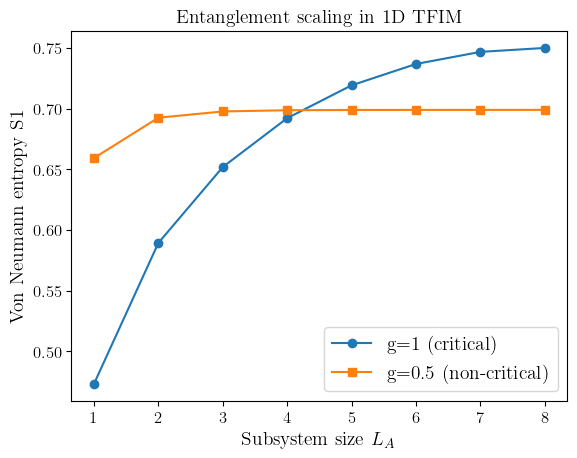

In [14]:
import matplotlib.pyplot as plt
plt.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
plt.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')
plt.xlabel("Subsystem size $L_A$")
plt.ylabel("Von Neumann entropy S1")
plt.title("Entanglement scaling in 1D TFIM")
plt.legend()
plt.show()

In [20]:
S2_critical = [renyi2_entropy_ED(gs_critical, L, LA) for LA in subsys_size] 
S2 = [renyi2_entropy_ED(gs, L, LA) for LA in subsys_size]

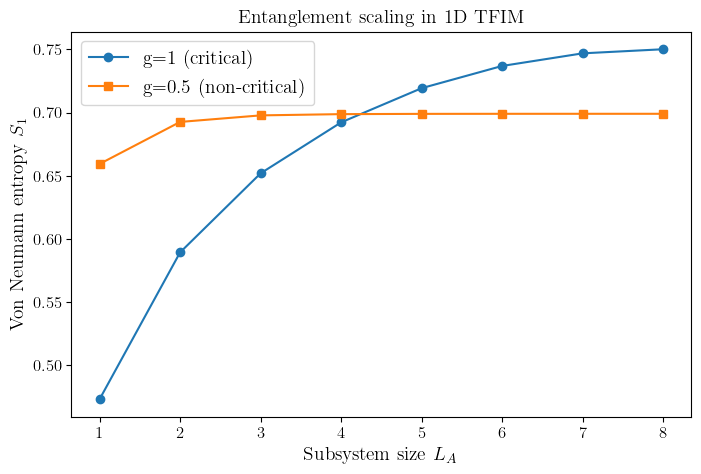

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

# main plot
ax.plot(subsys_size, S1_critical, 'o-', label='g=1 (critical)')
ax.plot(subsys_size, S1, 's-', label='g=0.5 (non-critical)')
ax.set_xlabel("Subsystem size $L_A$")
ax.set_ylabel("Von Neumann entropy $S_1$")
ax.legend()
ax.set_title("Entanglement scaling in 1D TFIM")

plt.savefig("vonneumann.png", dpi = 300)
plt.show()


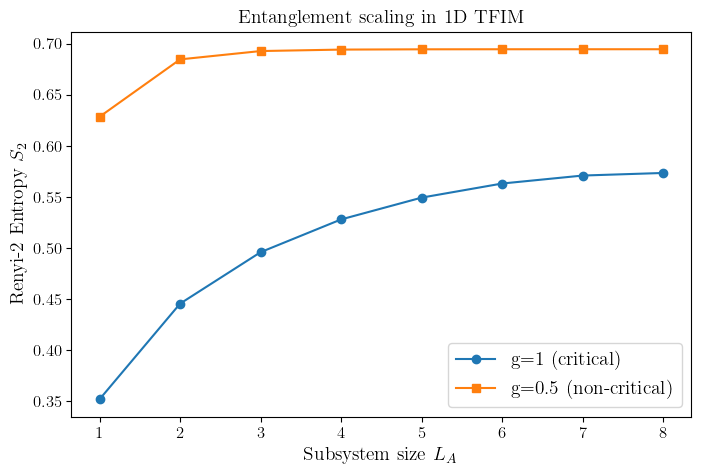

In [21]:
fig, ax = plt.subplots(figsize=(8,5))

# main plot
ax.plot(subsys_size, S2_critical, 'o-', label='g=1 (critical)')
ax.plot(subsys_size, S2, 's-', label='g=0.5 (non-critical)')
ax.set_xlabel("Subsystem size $L_A$")
ax.set_ylabel("Renyi-2 Entropy $S_2$")
ax.legend()
ax.set_title("Entanglement scaling in 1D TFIM")

plt.savefig("renyi2.png", dpi = 300)
plt.show()